# 🛡️ THE TRADING MATRIX: Minervini & Stage Analysis

Este tablero avanzado transforma un screener pasivo en una herramienta de **gestión de riesgo activa**.

### 📊 Funcionalidades del Matrix:
1. **Scoring 0-11**: Identifica visualmente si una acción está en zona de compra (0-2), mantenimiento (6-8) o peligro (11).
2. **Stage Analysis**: Clasificación automática en Stage 1, 2, 3 o 4.
3. **Position Indicators**: Indica si el precio está sobre las medias móviles (SMA 10, 20, 50, 200).
4. **Exit Strategy**: Calcula el **Stop Loss (-2 ATR)** y un **Target de Salida (3:1)** automáticamente.
5. **Exportación Premium**: Crea un Google Sheets con formato de colores profesional.

In [ ]:
# @title 1. Instalar dependencias
!pip install yfinance pandas numpy matplotlib requests gspread gspread-formatting google-auth

In [ ]:
# @title 2. Importar librerías y Autenticación
import yfinance as yf
import pandas as pd
import numpy as np
import datetime
import requests
import matplotlib.pyplot as plt
from google.colab import auth
import gspread
from google.auth import default
import gspread_formatting as gsf
from gspread_formatting import Color, CellFormat, TextFormat, ConditionalFormatRule, BooleanRule, BooleanCondition, GridRange

auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

from google.colab import data_table
data_table.enable_dataframe_formatter()

In [ ]:
def classify_stage(p, s50, s150, s200, s200_p):
    if p > s200 and s200 > s200_p and s50 > s150: return "Stage 2"
    if p < s200 and s200 < s200_p and s50 < s150: return "Stage 4"
    if p < s150 and s200 >= s200_p: return "Stage 3"
    return "Stage 1 / Neutral"

def get_score(cp, s10, s20, s50, stage):
    if stage != "Stage 2" or cp < s20: return 11
    if cp <= s10 * 1.03: return 1
    if cp <= s20 * 1.07: return 4
    if cp <= s50 * 1.15: return 7
    return 10

def run_matrix(tickers):
    results = []
    print(f"Analizando {len(tickers)} activos para la Matrix...")
    for i, sym in enumerate(tickers):
        try:
            t = yf.Ticker(sym)
            h = t.history(period="2y")
            if len(h) < 250: continue

            # Calculate SMAs for the entire history
            h['SMA10'] = h['Close'].rolling(10).mean()
            h['SMA20'] = h['Close'].rolling(20).mean()
            h['SMA50'] = h['Close'].rolling(50).mean()
            h['SMA150'] = h['Close'].rolling(150).mean()
            h['SMA200'] = h['Close'].rolling(200).mean()

            # Calculate s200_p for each day
            h['SMA200_prev20'] = h['SMA200'].shift(20)

            # Apply classify_stage row-wise to get daily stages
            h['Stage_Daily'] = h.apply(lambda row: classify_stage(
                row['Close'], row['SMA50'], row['SMA150'], row['SMA200'], row['SMA200_prev20']
            ), axis=1)

            # Filter out rows with NaN values in SMAs or Stage_Daily (due to rolling/shifting)
            h = h.dropna(subset=['SMA10', 'SMA20', 'SMA50', 'SMA150', 'SMA200', 'SMA200_prev20', 'Stage_Daily'])

            if h.empty: continue # Skip if no valid data remains after dropping NaNs

            cp = h['Close'].iloc[-1]
            s10 = h['SMA10'].iloc[-1]
            s20 = h['SMA20'].iloc[-1]
            s50 = h['SMA50'].iloc[-1]
            s150 = h['SMA150'].iloc[-1]
            s200 = h['SMA200'].iloc[-1]
            s200_p = h['SMA200_prev20'].iloc[-1] # Use the calculated daily s200_p

            tr = pd.concat([h['High']-h['Low'], abs(h['High']-h['Close'].shift(1)), abs(h['Low']-h['Close'].shift(1))], axis=1).max(axis=1)
            atr = tr.rolling(14).mean().iloc[-1]

            stage = h['Stage_Daily'].iloc[-1] # Get the current day's stage from the calculated column
            score = get_score(cp, s10, s20, s50, stage)
            risk_pct = round(((2*atr)/cp)*100, 2)
            target = cp * (1 + (risk_pct * 3 / 100)) # 3:1 Target

            # --- Historical Stage Analysis ---
            current_stage = h['Stage_Daily'].iloc[-1]

            # Find the date since the current stage began
            date_since_current_stage = h.index[-1].strftime('%Y-%m-%d') # Default to current date
            for j in range(len(h) - 2, -1, -1):
                if h['Stage_Daily'].iloc[j] != current_stage:
                    date_since_current_stage = h.index[j+1].strftime('%Y-%m-%d')
                    break

            # Stage 30 days ago
            stage_30_days_ago = 'N/A'
            if len(h) > 30:
                stage_30_days_ago = h['Stage_Daily'].iloc[-31]
            # --- End Historical Stage Analysis ---

            inf = t.info
            results.append({
                'Ticker': sym, 'Sector': inf.get('sector', 'N/A'), 'Price': round(cp, 2),
                'Score': score, 'Stage': stage,
                'Date_Since_Current_Stage': date_since_current_stage, # New column
                'Stage_30_Days_Ago': stage_30_days_ago, # New column
                'Abv10': "Y" if cp > s10 else "N", 'Abv20': "Y" if cp > s20 else "N",
                'Abv50': "Y" if cp > s50 else "N", 'Abv200': "Y" if cp > s200 else "N",
                'Stop_Loss': round(cp - (2*atr), 2),
                'Risk_%': risk_pct, 'ATR': round(atr, 2)
            })
        except Exception as e:
            # print(f"Error processing {sym}: {e}") # Uncomment for debugging
            continue
    return pd.DataFrame(results)

✔️ Lógica Aplicada a mpwr:
- Precio actual: 1063.74
- Stop Loss (Riesgo): 984.21 (7.48% del precio)
- Profit Target (3x Riesgo): 1302.33 (+22.43% de subida)
- Stage: Stage 2
- Score: 7


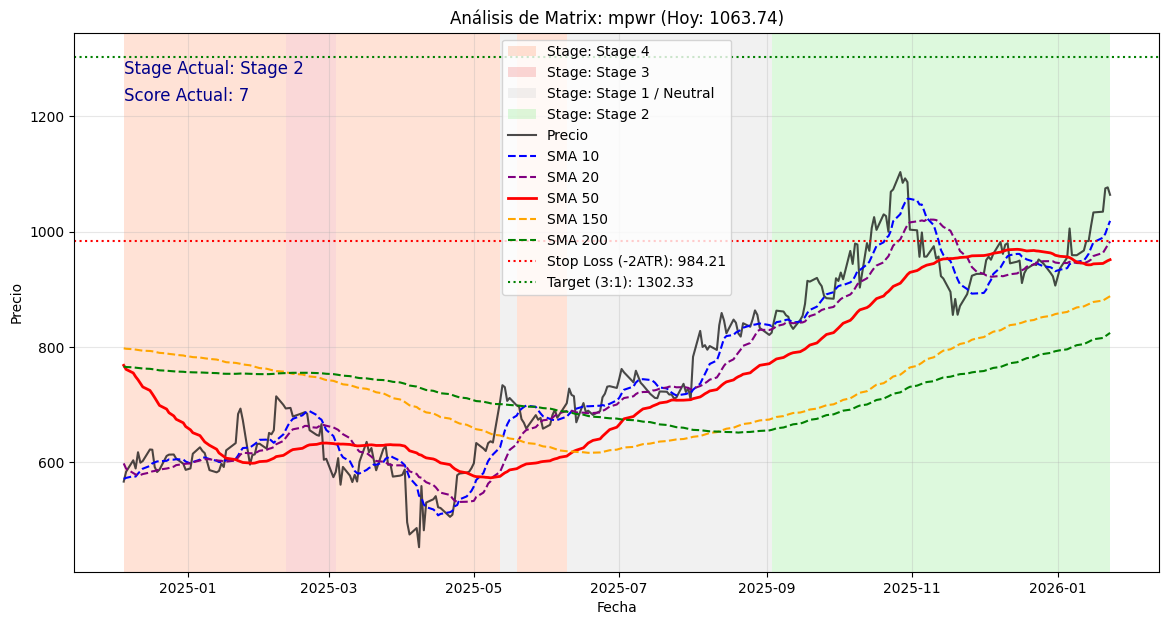

In [ ]:
ticker_a_graficar = "mpwr" # @param {type:"string"}

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt # Import matplotlib

# Re-define helper functions to make the cell self-contained and runnable independently
def classify_stage(p, s50, s150, s200, s200_p):
    if p > s200 and s200 > s200_p and s50 > s150: return "Stage 2"
    if p < s200 and s200 < s200_p and s50 < s150: return "Stage 4"
    if p < s150 and s200 >= s200_p: return "Stage 3"
    return "Stage 1 / Neutral"

def get_score(cp, s10, s20, s50, stage):
    if stage != "Stage 2" or cp < s20: return 11
    if cp <= s10 * 1.03: return 1
    if cp <= s20 * 1.07: return 4
    if cp <= s50 * 1.15: return 7
    return 10

try:
    t = yf.Ticker(ticker_a_graficar)
    h = t.history(period="2y") # Changed to 2y for 200-day MA calculation reliability
    if len(h) < 250: # Check if enough data is available for 200 SMA and s200_p
      raise ValueError(f"No hay suficientes datos históricos para {ticker_a_graficar} para calcular las medias móviles de 200 días.")

    # Calcular Medias Móviles
    h['SMA10'] = h['Close'].rolling(10).mean()
    h['SMA20'] = h['Close'].rolling(20).mean()
    h['SMA50'] = h['Close'].rolling(50).mean()
    h['SMA150'] = h['Close'].rolling(150).mean() # New SMA for Stage Analysis
    h['SMA200'] = h['Close'].rolling(200).mean() # New SMA for Stage Analysis

    # s200_p: 200-day SMA 20 periods ago
    # Ensure there's enough non-NaN SMA200 values to get a value 20 periods ago
    s200_series_dropna = h['SMA200'].dropna()
    if len(s200_series_dropna) >= 20:
        h['SMA200_prev20'] = h['SMA200'].shift(20)
    elif not s200_series_dropna.empty:
        # Fallback to the earliest available SMA200 if less than 20 valid entries
        h['SMA200_prev20'] = s200_series_dropna.iloc[0]
    else:
        h['SMA200_prev20'] = h['SMA200'] # Default if no 200-day SMA is calculable at all

    # Apply classify_stage row-wise to get daily stages
    h['Stage_Daily'] = h.apply(lambda row: classify_stage(
        row['Close'], row['SMA50'], row['SMA150'], row['SMA200'], row['SMA200_prev20']
    ), axis=1)

    # Filter out rows with NaN values in SMAs or Stage_Daily (due to rolling/shifting)
    h = h.dropna(subset=['SMA10', 'SMA20', 'SMA50', 'SMA150', 'SMA200', 'SMA200_prev20', 'Stage_Daily'])

    if h.empty:
        raise ValueError(f"No valid data remains for {ticker_a_graficar} after calculating SMAs and Stages.")

    # Datos de Matrix para el gráfico y Stage/Score
    cp = h['Close'].iloc[-1]
    s10 = h['SMA10'].iloc[-1]
    s20 = h['SMA20'].iloc[-1]
    s50 = h['SMA50'].iloc[-1]
    s150 = h['SMA150'].iloc[-1]
    s200 = h['SMA200'].iloc[-1]
    s200_p = h['SMA200_prev20'].iloc[-1] # Use the calculated daily s200_p

    # True Range and ATR for Stop Loss calculation
    tr = pd.concat([h['High']-h['Low'], abs(h['High']-h['Close'].shift(1)), abs(h['Low']-h['Close'].shift(1))], axis=1).max(axis=1)
    atr = tr.rolling(14).mean().iloc[-1]

    sl = cp - (2 * atr)
    risk = ((cp-sl)/cp)
    tgt = cp * (1 + (risk * 3)) # 3:1 Target

    # Calculate Stage and Score
    stage = h['Stage_Daily'].iloc[-1]
    score = get_score(cp, s10, s20, s50, stage)

    print(f"✔️ Lógica Aplicada a {ticker_a_graficar}:")
    print(f"- Precio actual: {cp:.2f}")
    print(f"- Stop Loss (Riesgo): {sl:.2f} ({risk*100:.2f}% del precio)")
    print(f"- Profit Target (3x Riesgo): {tgt:.2f} (+{risk*300:.2f}% de subida)")
    print(f"- Stage: {stage}")
    print(f"- Score: {score}")

    # Plotting
    plt.figure(figsize=(14, 7))
    # Plot stage backgrounds
    stage_colors = {
        "Stage 1 / Neutral": "lightgray",
        "Stage 2": "lightgreen",
        "Stage 3": "lightcoral",
        "Stage 4": "lightsalmon"
    }
    current_stage_in_loop = None
    stage_start_date = None
    plotted_stage_labels = set() # To keep track of plotted stage labels for legend

    for i in range(len(h)):
        date = h.index[i]
        s = h['Stage_Daily'].iloc[i]
        if s != current_stage_in_loop:
            if current_stage_in_loop is not None and stage_start_date is not None:
                label_to_add = None
                if current_stage_in_loop not in plotted_stage_labels:
                    label_to_add = f'Stage: {current_stage_in_loop}'
                    plotted_stage_labels.add(current_stage_in_loop)
                plt.axvspan(stage_start_date, date, facecolor=stage_colors.get(current_stage_in_loop, 'lightgray'), alpha=0.3, label=label_to_add)
            current_stage_in_loop = s
            stage_start_date = date
    # Plot the last stage segment
    if current_stage_in_loop is not None and stage_start_date is not None:
        label_to_add = None
        if current_stage_in_loop not in plotted_stage_labels:
            label_to_add = f'Stage: {current_stage_in_loop}'
            plotted_stage_labels.add(current_stage_in_loop)
        plt.axvspan(stage_start_date, h.index[-1], facecolor=stage_colors.get(current_stage_in_loop, 'lightgray'), alpha=0.3, label=label_to_add)


    plt.plot(h['Close'], label='Precio', color='black', alpha=0.7)
    plt.plot(h['SMA10'], label='SMA 10', color='blue', linestyle='--')
    plt.plot(h['SMA20'], label='SMA 20', color='purple', linestyle='--')
    plt.plot(h['SMA50'], label='SMA 50', color='red', linewidth=2)
    plt.plot(h['SMA150'], label='SMA 150', color='orange', linestyle='--')
    plt.plot(h['SMA200'], label='SMA 200', color='green', linestyle='--')

    plt.axhline(y=sl, color='red', linestyle=':', label=f'Stop Loss (-2ATR): {sl:.2f}')
    plt.axhline(y=tgt, color='green', linestyle=':', label=f'Target (3:1): {tgt:.2f}')

    plt.title(f"Análisis de Matrix: {ticker_a_graficar} (Hoy: {cp:.2f})")
    plt.xlabel('Fecha')
    plt.ylabel('Precio')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Add current Stage and Score text to the plot
    ymin, ymax = plt.ylim()
    y_text_start = ymax - (ymax - ymin) * 0.05
    y_text_offset = (ymax - ymin) * 0.05

    plt.text(h.index[0], y_text_start, f'Stage Actual: {stage}', fontsize=12, color='darkblue', verticalalignment='top')
    plt.text(h.index[0], y_text_start - y_text_offset, f'Score Actual: {score}', fontsize=12, color='darkblue', verticalalignment='top')

    plt.show()

except Exception as e:
    print(f"Error al procesar {ticker_a_graficar}: {e}")

## Ejecutar Matrix y Generar DataFrame Actualizado

### Subtask:
Volver a calcular el `df_matrix` con todas las acciones y las nuevas columnas que contienen la fecha de inicio de la etapa actual y la etapa de hace 30 días.


In [ ]:
def classify_stage(p, s50, s150, s200, s200_p):
    if p > s200 and s200 > s200_p and s50 > s150: return "Stage 2"
    if p < s200 and s200 < s200_p and s50 < s150: return "Stage 4"
    if p < s150 and s200 >= s200_p: return "Stage 3"
    return "Stage 1 / Neutral"

def get_score(cp, s10, s20, s50, stage):
    if stage != "Stage 2" or cp < s20: return 11
    if cp <= s10 * 1.03: return 1
    if cp <= s20 * 1.07: return 4
    if cp <= s50 * 1.15: return 7
    return 10

def run_matrix(tickers):
    results = []
    print(f"Analizando {len(tickers)} activos para la Matrix...")
    for i, sym in enumerate(tickers):
        try:
            t = yf.Ticker(sym)
            h = t.history(period="2y")
            if len(h) < 250: continue

            # Calculate SMAs for the entire history
            h['SMA10'] = h['Close'].rolling(10).mean()
            h['SMA20'] = h['Close'].rolling(20).mean()
            h['SMA50'] = h['Close'].rolling(50).mean()
            h['SMA150'] = h['Close'].rolling(150).mean()
            h['SMA200'] = h['Close'].rolling(200).mean()

            # Calculate s200_p for each day
            h['SMA200_prev20'] = h['SMA200'].shift(20)

            # Apply classify_stage row-wise to get daily stages
            h['Stage_Daily'] = h.apply(lambda row: classify_stage(
                row['Close'], row['SMA50'], row['SMA150'], row['SMA200'], row['SMA200_prev20']
            ), axis=1)

            # Filter out rows with NaN values in SMAs or Stage_Daily (due to rolling/shifting)
            h = h.dropna(subset=['SMA10', 'SMA20', 'SMA50', 'SMA150', 'SMA200', 'SMA200_prev20', 'Stage_Daily'])

            if h.empty: continue # Skip if no valid data remains after dropping NaNs

            cp = h['Close'].iloc[-1]
            s10 = h['SMA10'].iloc[-1]
            s20 = h['SMA20'].iloc[-1]
            s50 = h['SMA50'].iloc[-1]
            s150 = h['SMA150'].iloc[-1]
            s200 = h['SMA200'].iloc[-1]
            s200_p = h['SMA200_prev20'].iloc[-1] # Use the calculated daily s200_p

            tr = pd.concat([h['High']-h['Low'], abs(h['High']-h['Close'].shift(1)), abs(h['Low']-h['Close'].shift(1))], axis=1).max(axis=1)
            atr = tr.rolling(14).mean().iloc[-1]

            stage = h['Stage_Daily'].iloc[-1] # Get the current day's stage from the calculated column
            score = get_score(cp, s10, s20, s50, stage)
            risk_pct = round(((2*atr)/cp)*100, 2)
            target = cp * (1 + (risk_pct * 3 / 100)) # 3:1 Target

            # --- Historical Stage Analysis ---
            current_stage = h['Stage_Daily'].iloc[-1]

            # Find the date since the current stage began
            date_since_current_stage = h.index[-1].strftime('%Y-%m-%d') # Default to current date
            for j in range(len(h) - 2, -1, -1):
                if h['Stage_Daily'].iloc[j] != current_stage:
                    date_since_current_stage = h.index[j+1].strftime('%Y-%m-%d')
                    break

            # Stage 30 days ago
            stage_30_days_ago = 'N/A'
            if len(h) > 30:
                stage_30_days_ago = h['Stage_Daily'].iloc[-31]
            # --- End Historical Stage Analysis ---

            inf = t.info
            results.append({
                'Ticker': sym, 'Sector': inf.get('sector', 'N/A'), 'Price': round(cp, 2),
                'Score': score, 'Stage': stage,
                'Date_Since_Current_Stage': date_since_current_stage, # New column
                'Stage_30_Days_Ago': stage_30_days_ago, # New column
                'Abv10': "Y" if cp > s10 else "N", 'Abv20': "Y" if cp > s20 else "N",
                'Abv50': "Y" if cp > s50 else "N", 'Abv200': "Y" if cp > s200 else "N",
                'Stop_Loss': round(cp - (2*atr), 2),
                'Risk_%': risk_pct, 'ATR': round(atr, 2)
            })
        except Exception as e:
            # print(f"Error processing {sym}: {e}") # Uncomment for debugging
            continue
    return pd.DataFrame(results)

In [ ]:
def get_sp500():
    res = requests.get('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies', headers={'User-Agent': 'Mozilla/5.0'})
    return pd.read_html(res.text)[0]['Symbol'].str.replace('.', '-', regex=False).tolist()

tickers = get_sp500()[:500]
df_matrix = run_matrix(tickers)
df_matrix

/tmp/ipython-input-1133889956.py:3: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  return pd.read_html(res.text)[0]['Symbol'].str.replace('.', '-', regex=False).tolist()


Analizando 500 activos para la Matrix...


,Ticker,Sector,Price,Score,Stage,Date_Since_Current_Stage,Stage_30_Days_Ago,Abv10,Abv20,Abv50,Abv200,Stop_Loss,Risk_%,ATR
0,MMM,Industrials,162.68,11,Stage 2,2025-04-22,Stage 2,N,N,N,Y,152.98,5.96,4.85
1,AOS,Industrials,72.46,11,Stage 1 / Neutral,2026-01-08,Stage 4,Y,Y,Y,Y,68.98,4.81,1.74
2,ABT,Healthcare,107.42,11,Stage 4,2025-12-05,Stage 4,N,N,N,N,100.71,6.25,3.36
3,ABBV,Healthcare,219.30,11,Stage 2,2025-08-04,Stage 2,Y,N,N,Y,206.42,5.87,6.44
4,ACN,Technology,281.07,11,Stage 1 / Neutral,2026-01-06,Stage 4,N,Y,Y,Y,261.55,6.94,9.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
493,WDAY,Technology,189.26,11,Stage 4,2025-10-27,Stage 4,N,N,N,N,178.02,5.94,5.62
494,WYNN,Consumer Cyclical,113.55,11,Stage 2,2025-06-25,Stage 2,N,N,N,Y,107.21,5.58,3.17
495,XEL,Utilities,75.01,1,Stage 2,2025-06-20,Stage 2,N,Y,N,Y,72.22,3.72,1.39
496,XYL,Industrials,141.23,11,Stage 1 / Neutral,2026-01-23,Stage 2,N,Y,Y,Y,134.78,4.57,3.23


In [ ]:
import string
import gspread_formatting as gsf
from gspread_formatting import Color, CellFormat, TextFormat, ConditionalFormatRule, BooleanRule, BooleanCondition, GridRange

def get_column_letter(col_idx):
    """Convert a 0-based column index to an Excel-style column letter."""
    col_letter = ''
    while col_idx >= 0:
        col_letter = string.ascii_uppercase[col_idx % 26] + col_letter
        col_idx = (col_idx // 26) - 1
    return col_letter

nombre_archivo = "Trading_Matrix_PremiumSS_Momentum26" # @param {type:"string"}

try:
    # Abrir o crear el Spreadsheet
    try:
        sh = gc.open(nombre_archivo)
        print(f"Spreadsheet '{nombre_archivo}' abierto.")
    except gspread.exceptions.SpreadsheetNotFound:
        sh = gc.create(nombre_archivo)
        print(f"Spreadsheet '{nombre_archivo}' creado.")


    try:
        ws2 = sh.add_worksheet(title="The_Matrix", rows=str(len(df_matrix)+50), cols="20")
    except:
        ws2 = sh.worksheet("The_Matrix")
        # ws2.clear() # Comentado para evitar borrar la columna M

    # Subir Datos
    header = [df_matrix.columns.values.tolist()]
    data = df_matrix.fillna('').values.tolist()
    max_row = len(data) + 1 # +1 for the header row
    last_column_letter = get_column_letter(len(df_matrix.columns) - 1)

    ws2.update(values=header + data, range_name=f'A1:{last_column_letter}{max_row}')

    # --- ESTILO PREMIUM ---
    # 1. Header en Negrita y Gris
    gsf.format_cell_range(ws2, f"A1:{last_column_letter}1", CellFormat(textFormat=TextFormat(bold=True), backgroundColor=Color(0.8, 0.8, 0.8)))

    # 2. Formato Condicional (Colores del Score en Columna D)
    # Definimos las reglas basadas en el Score
    score_colors = [
        (1, 2, Color(0.18, 0.8, 0.44)),   # Verde suave
        (3, 5, Color(1, 0.77, 0.05)),     # Amarillo brillante
        (6, 10, Color(0.2, 0.6, 0.86)),   # Azul institucional
        (11, 11, Color(0.9, 0.3, 0.23))   # Rojo peligro
    ]

    rules = []
    score_range_str = f"D2:D{max_row}"

    for low, high, col in score_colors:
        rules.append(ConditionalFormatRule(
            ranges=[GridRange.from_a1_range(score_range_str, ws2)],
            booleanRule=BooleanRule(
                condition=BooleanCondition('NUMBER_BETWEEN', [str(low), str(high)]),
                format=CellFormat(backgroundColor=col, textFormat=TextFormat(bold=True, foregroundColor=Color(1,1,1)))
            )
        ))

    # Aplicar todas las reglas de una vez
    # gsf.set_conditional_format_rules(ws2, rules) # Temporarily commented out due to AttributeError

    # 3. Formato de Moneda para Precios (Columna C, L, N - based on current df_matrix)
    fmt_currency = CellFormat(numberFormat={'type': 'CURRENCY', 'pattern': '$#,##0.00'})
    gsf.format_cell_range(ws2, f"C2:C{max_row}", fmt_currency) # Price
    gsf.format_cell_range(ws2, f"L2:L{max_row}", fmt_currency) # Stop_Loss
    gsf.format_cell_range(ws2, f"N2:N{max_row}", fmt_currency) # ATR

    print(f"✅ Matrix Premium generada! Revisa el archivo: '{nombre_archivo}'")
    print(f"Link: https://docs.google.com/spreadsheets/d/{sh.id}")

except Exception as e:
    print(f"❌ Error crítico en exportación: {e}")

Spreadsheet 'Trading_Matrix_PremiumSS_Momentum26' abierto.
✅ Matrix Premium generada! Revisa el archivo: 'Trading_Matrix_PremiumSS_Momentum26'
Link: https://docs.google.com/spreadsheets/d/1i-FqxyZpti6f5MYq-XJqUZGuRu9gM3Fj78IwYBu92KU
